In [1]:
import os,sys
import numpy as np
import pandas as pd
import scanpy as sc
from scanpy import AnnData
sc.set_figure_params(figsize=(4,4))
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype']=42
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from scanpy import AnnData

In [2]:
meta=pd.read_csv('../metadata_passQC_05212026.tsv.gz',sep='\t').set_index('ID')
meta.head(1)

,L1,L2,L3,L4,age,age_groups,region,mCG/CG_global,mCH/CH_global,mCCC/CCC_global,...,pairs_enzymeless_intra20kb,pairs_enzymeless_inter,pairs_dup_rate,high_coverage_pairs,allc_input_genome_coverage_dup,allc_input_genome_coverage_dedup,allc_input_mapped_bp_dup,allc_input_mapped_bp_dedup,mCG/CG_chrL,mCH/CH_chrL
ID,,,,,,,,,,,,,,,,,,,,,
20210111-1863-preAb-PFC-B12_A1,Exc,UL,L1-3-CUX2,L1-3-CUX2,31,adult,DFC,0.77233,0.059992,0.012849,...,4499.0,1399.0,0.377175,81.0,44221255.0,44221255.0,45085203.0,45085203.0,NaN,NaN


In [3]:
adata=sc.read_h5ad('../../Annotate/5kb_Annotate/allMSN_10142025.h5ad')
print(adata.shape)

(24507, 49073)


In [4]:
for c in meta.columns:
    adata.obs[c]=meta[c]

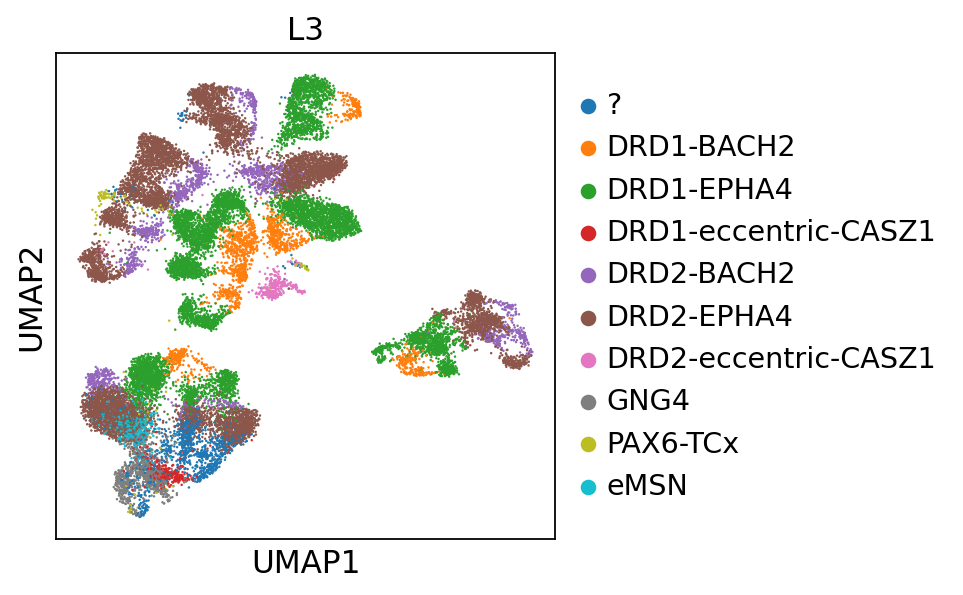

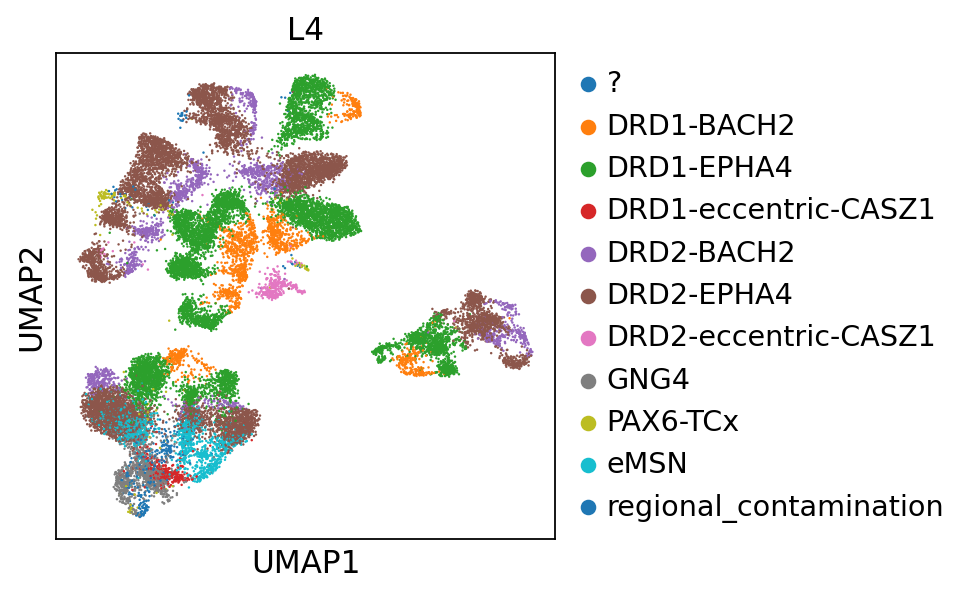

In [5]:
sc.pl.umap(adata,color='L3',palette=sc.pl.palettes.vega_10)
sc.pl.umap(adata,color='L4',palette=sc.pl.palettes.vega_10)

In [6]:
pd.crosstab(meta[meta['L2']=='MSN']['L4'],meta[meta['L2']=='MSN']['L3'])

L3,?,DRD1-BACH2,DRD1-EPHA4,DRD1-eccentric-CASZ1,DRD2-BACH2,DRD2-EPHA4,DRD2-eccentric-CASZ1,GNG4,PAX6-TCx,eMSN
L4,,,,,,,,,,
?,766,0,0,0,0,0,0,0,0,2
DRD1-BACH2,0,1695,0,0,0,0,0,0,0,0
DRD1-EPHA4,0,0,8359,0,0,0,0,0,0,0
DRD1-eccentric-CASZ1,0,0,0,1414,0,0,0,0,0,0
DRD2-BACH2,0,0,0,0,1797,0,0,0,0,0
DRD2-EPHA4,0,0,0,0,0,9172,0,0,0,0
DRD2-eccentric-CASZ1,0,0,0,0,0,0,303,0,0,0
GNG4,0,0,0,0,0,0,0,1411,0,0
PAX6-TCx,0,0,0,0,0,0,0,0,720,0


In [7]:
df2=adata.obs
adata.obs['aL123']=adata.obs['fine_age_groups'].astype(str)+'_'+adata.obs['L1'].astype(str)+'_'+adata.obs['L2'].astype(str)+'_'+adata.obs['L4'].astype(str)
counts=pd.DataFrame(adata.obs['aL123'].value_counts())

In [8]:
adata2=adata[adata.obs['L3'].isin(['DRD1-EPHA4','eMSN'])]

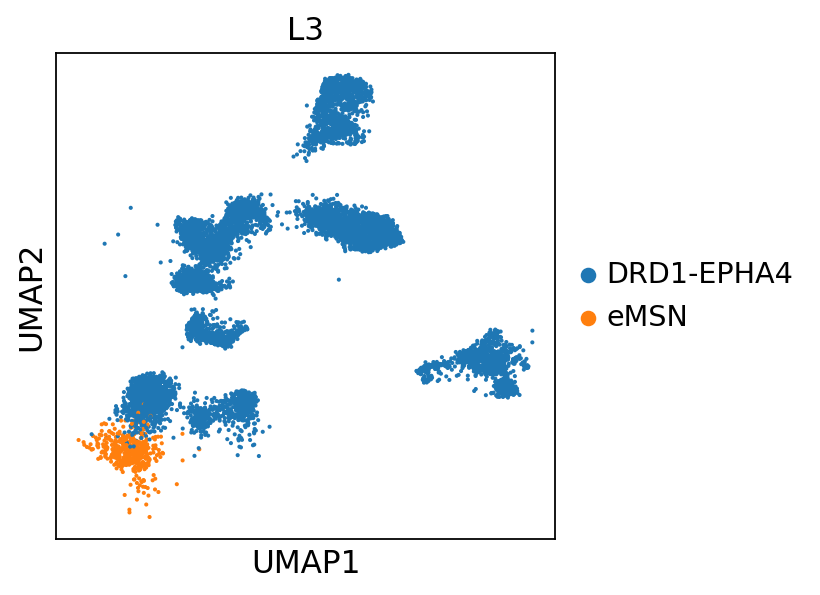

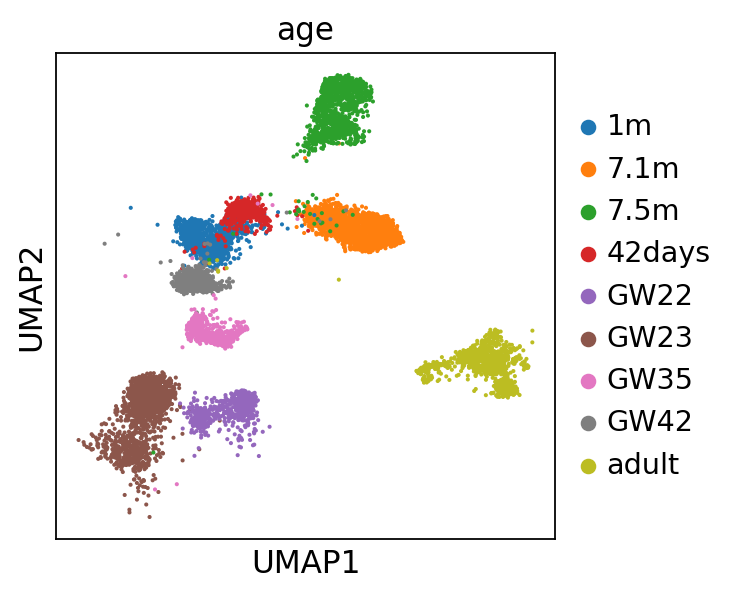

In [9]:
sc.pl.umap(adata2,color='L3',palette=sc.pl.palettes.vega_10)
sc.pl.umap(adata2,color='age',palette=sc.pl.palettes.vega_10)

In [10]:
adata.obsm

AxisArrays with keys: X_pca_100kb, X_pca_3C, X_pca_3C-100k, X_pca_3C-10k, X_pca_5kb, X_umap, X_umap_5kb

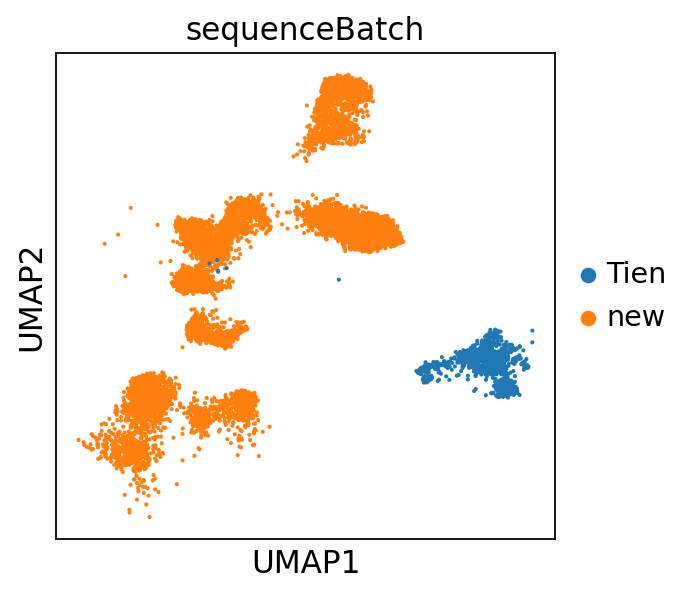

In [11]:
sc.pl.umap(adata2,color='sequenceBatch')

In [12]:
adata2=adata2[adata2.obs['L4'].isin(['DRD1-EPHA4','eMSN'])]
adata2=adata2[~adata2.obs['Case'].isin(['UCSF2303'])]

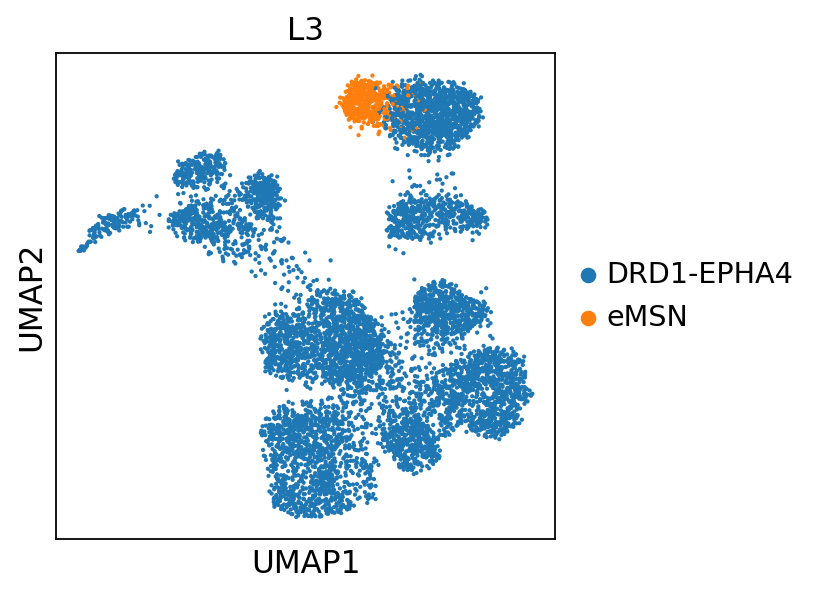

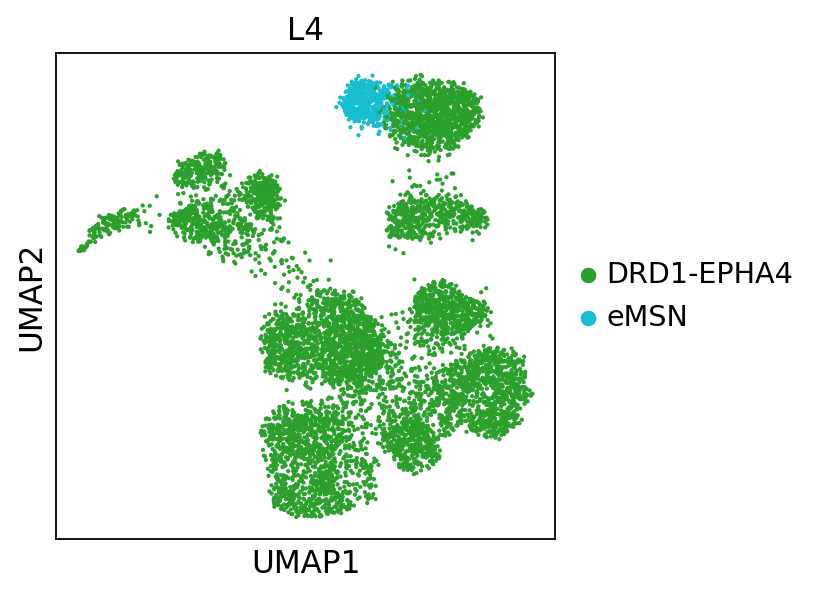

In [13]:
sc.pp.neighbors(adata2,use_rep='X_pca_5kb')
sc.tl.umap(adata2)
# sc.pl.umap(adata2,color='sequenceBatch_O-N')
sc.pl.umap(adata2,color='L3',palette=sc.pl.palettes.vega_10)
sc.pl.umap(adata2,color='L4')

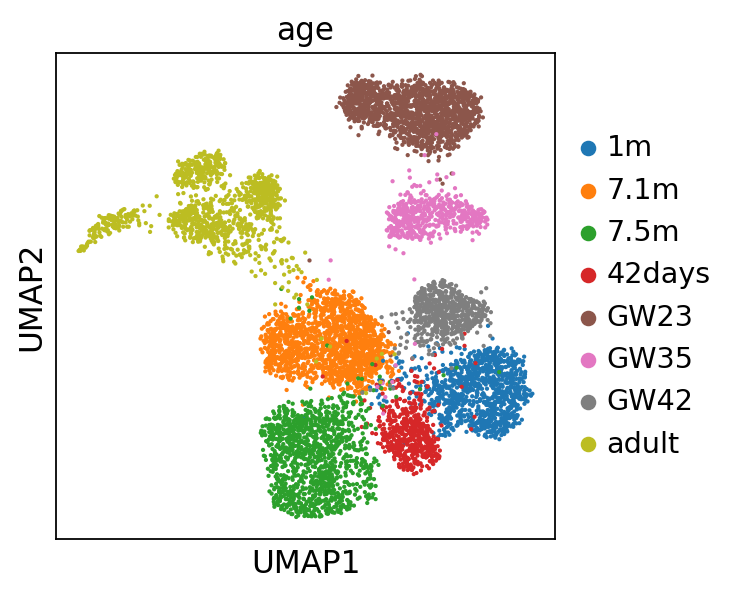

In [14]:
sc.pl.umap(adata2,color='age')

In [15]:
mdata=adata2.copy()

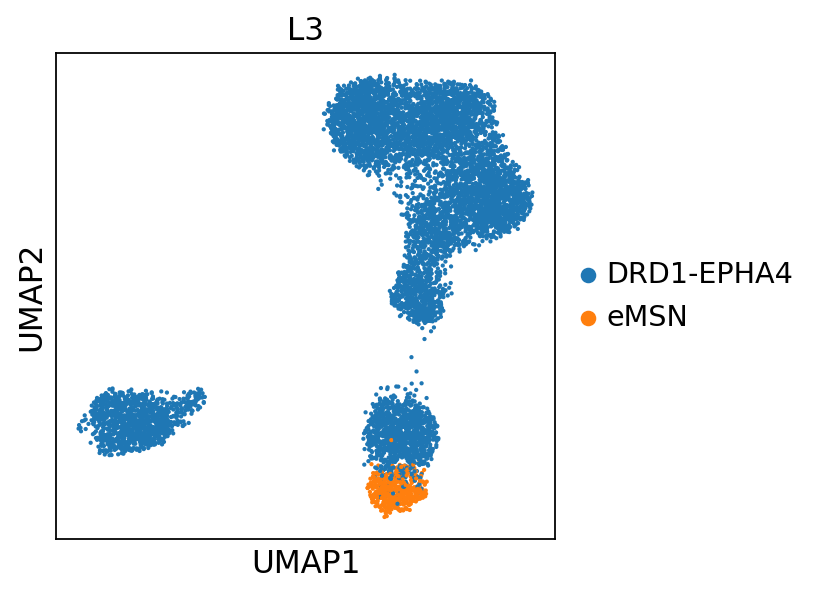

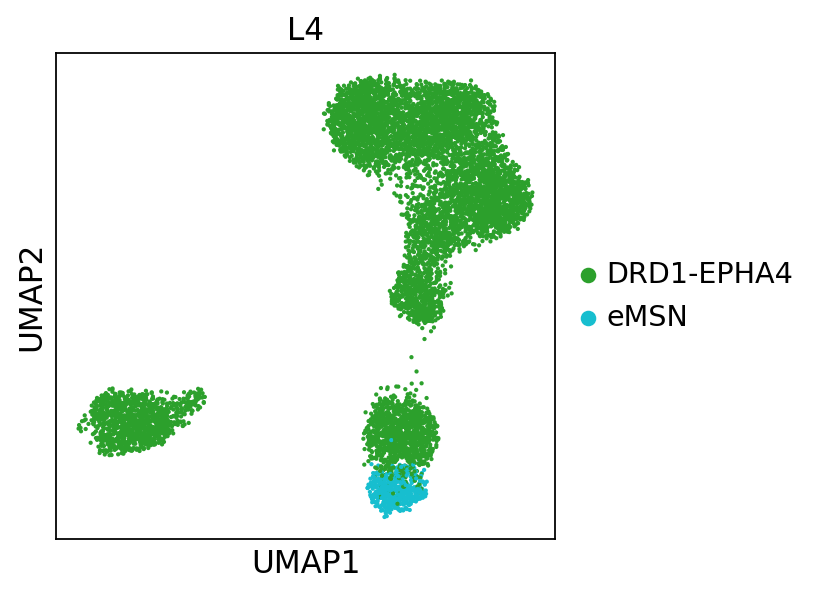

In [16]:
sc.pp.neighbors(adata2,use_rep='X_pca_3C')
sc.tl.umap(adata2)
sc.pl.umap(adata2,color='L3')
sc.pl.umap(adata2,color='L4')

In [17]:
cdata=adata2.copy()

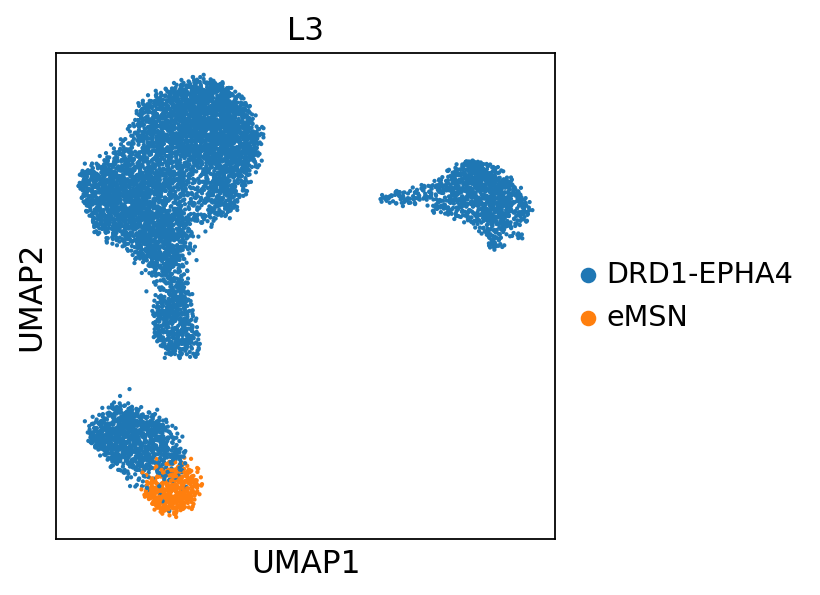

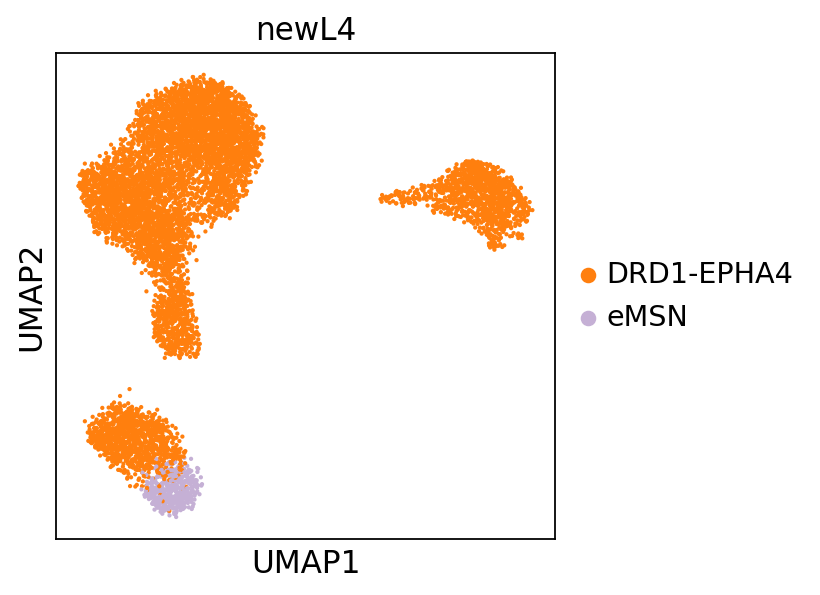

In [18]:
adata2.obsm['X_pca_3C-10k']=np.concatenate((adata2.obsm['X_pca_3C'][:, :20], adata2.obsm['X_pca_5kb'][:, :20]*45), axis=1)
sc.pp.neighbors(adata2,use_rep='X_pca_3C-10k')
sc.tl.umap(adata2)
sc.pl.umap(adata2,color='L3',palette=sc.pl.palettes.vega_10)
sc.pl.umap(adata2,color='newL4')

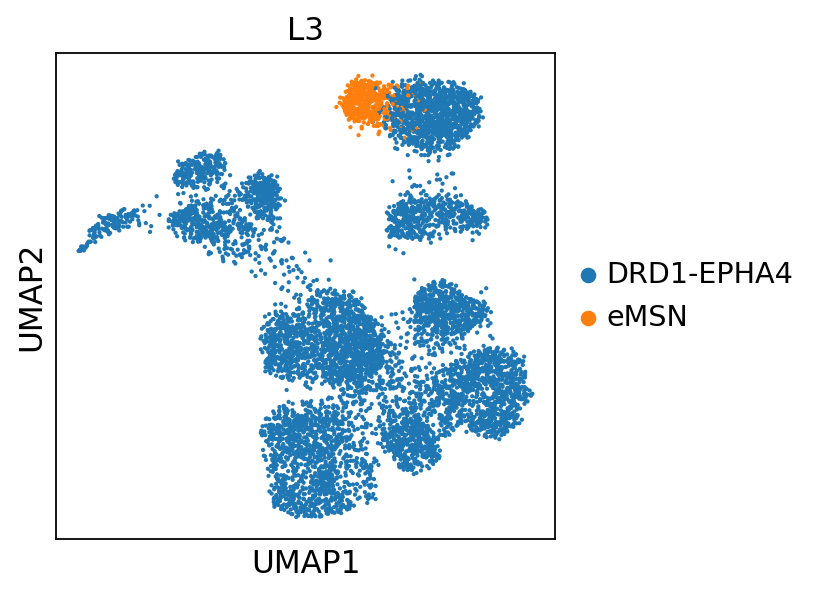

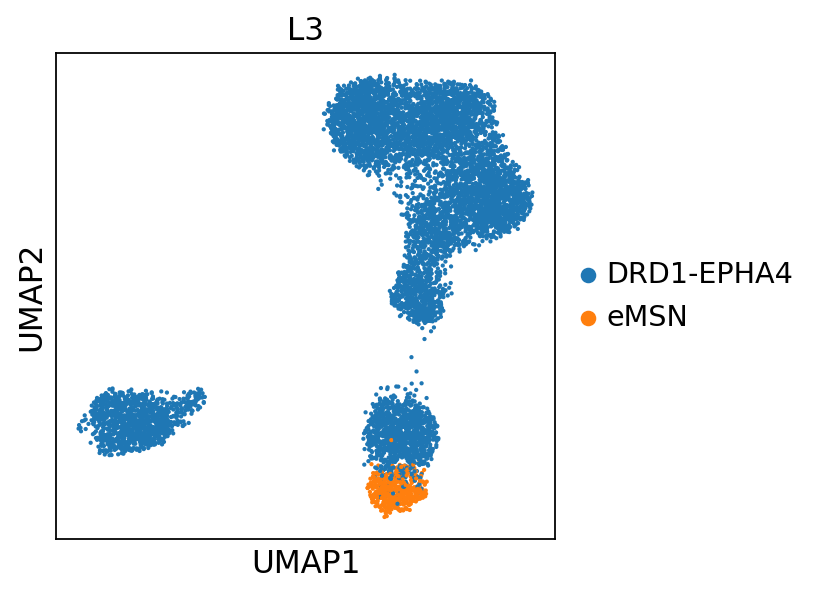

In [19]:
sc.pl.umap(mdata,color='L3')
sc.pl.umap(cdata,color='L3')

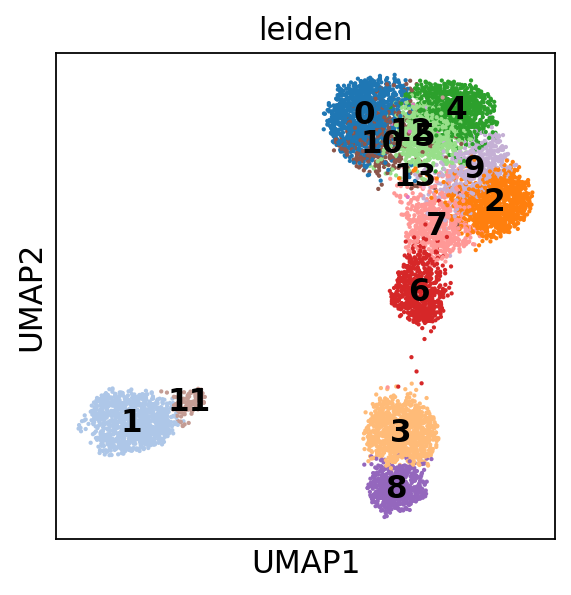

In [20]:
sc.tl.leiden(cdata,resolution=2)
mdata.obs['leiden']=cdata.obs['leiden']
sc.pl.umap(cdata,color='leiden',legend_loc='on data',palette=sc.pl.palettes.vega_20)

In [21]:
#find root node
# for i in range(2000):
#     print(i)
#     mdata.uns['iroot'] = np.flatnonzero(mdata.obs['leiden']  == '8')[i]
#     cdata.uns['iroot'] = np.flatnonzero(cdata.obs['leiden']  == '8')[i]
#     sc.tl.dpt(mdata)
#     sc.tl.dpt(cdata)
#     sc.pl.umap(mdata,color='dpt_pseudotime',vmax=.5,cmap='turbo')
#     sc.pl.umap(cdata,color='dpt_pseudotime',vmax=.5,cmap='turbo')

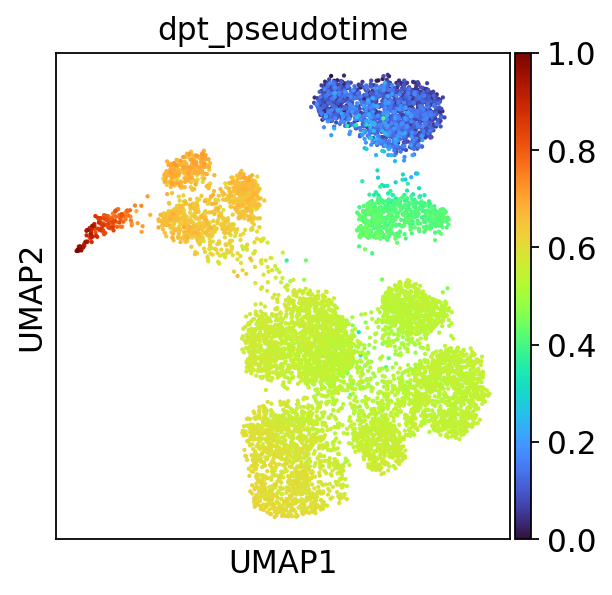

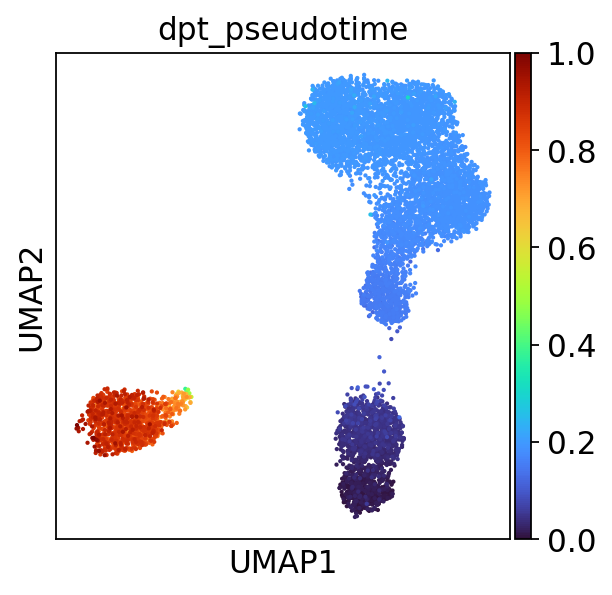

In [22]:
mdata.uns['iroot'] = np.flatnonzero(mdata.obs['leiden']  == '8')[6]
cdata.uns['iroot'] = np.flatnonzero(cdata.obs['leiden']  == '8')[6]
sc.tl.dpt(mdata)
sc.tl.dpt(cdata)
sc.pl.umap(mdata,color='dpt_pseudotime',vmax=1,cmap='turbo')
sc.pl.umap(cdata,color='dpt_pseudotime',vmax=1,cmap='turbo')

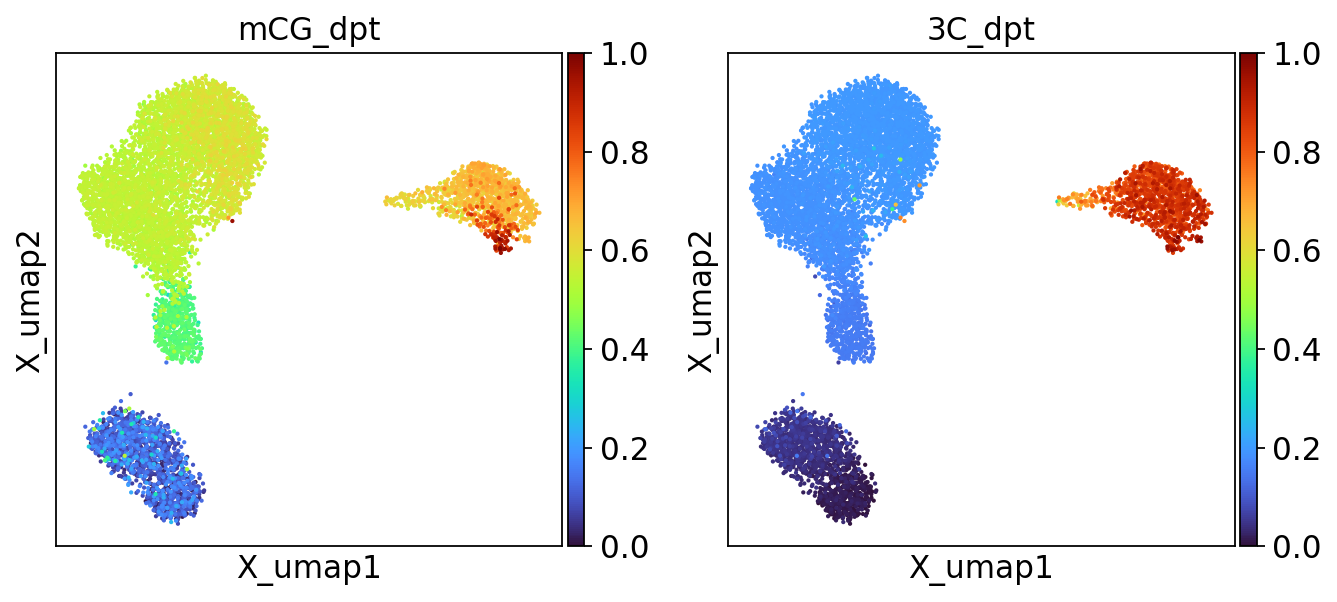

In [23]:
mdata.obs['3C_dpt']=cdata.obs['dpt_pseudotime']
mdata.obs['mCG_dpt']=mdata.obs['dpt_pseudotime']
adata2.obs['3C_dpt']=cdata.obs['dpt_pseudotime']
adata2.obs['mCG_dpt']=mdata.obs['dpt_pseudotime']
sc.pl.embedding(adata2,basis='X_umap',color=['mCG_dpt','3C_dpt'],cmap='turbo')

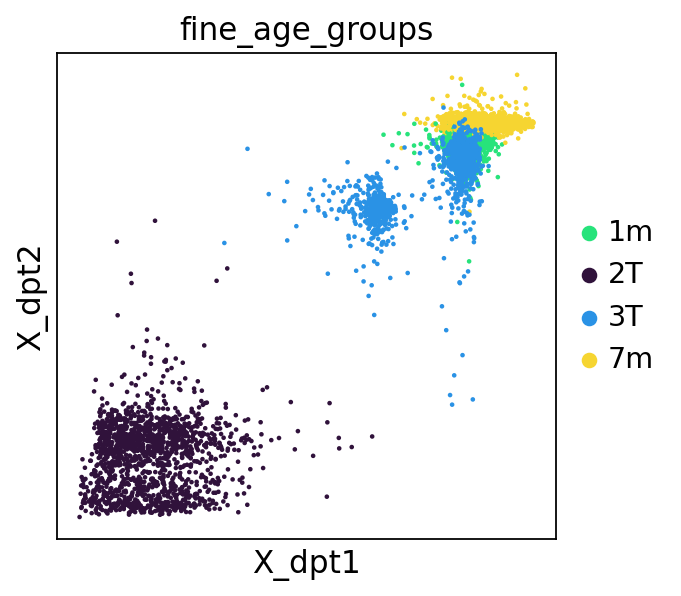

In [24]:
adata2.obsm['X_dpt']=adata2.obs[['mCG_dpt','3C_dpt']].values
adata3=adata2[adata2.obs['fine_age_groups']!='adult']
sc.pl.embedding(adata3,basis='X_dpt',color=['fine_age_groups'],
                palette=['#27e37b','#30123b','#2a92e5','#f6d531','#aa40fc'],save='MSN-D1EPHA4_mmxDPT_no adult.pdf')


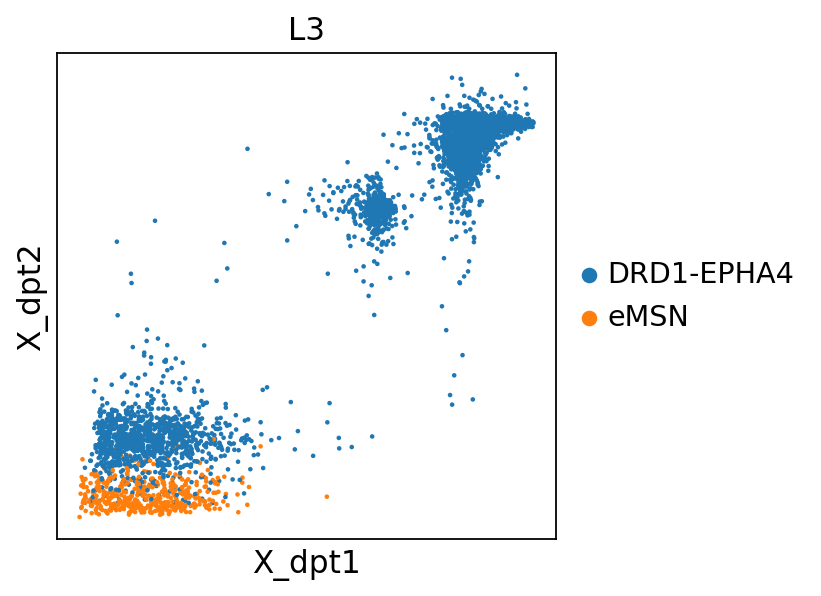

In [25]:
sc.pl.embedding(adata3,basis='X_dpt',color=['L3'])

In [26]:
adata2.obs['region']=meta['region']
adata2.obs['tr']=adata2.obs['region']
for i in adata2.obs['tr'].unique():
    if i!='LV':
        adata2.obs['tr']=adata2.obs['tr'].replace(i,'')
    else:
        adata2.obs['tr']=adata2.obs['tr'].replace(i,'LV_')
adata2.obs['rAge']=adata2.obs['tr'].astype(str)+''+adata2.obs['fine_age_groups'].astype(str)

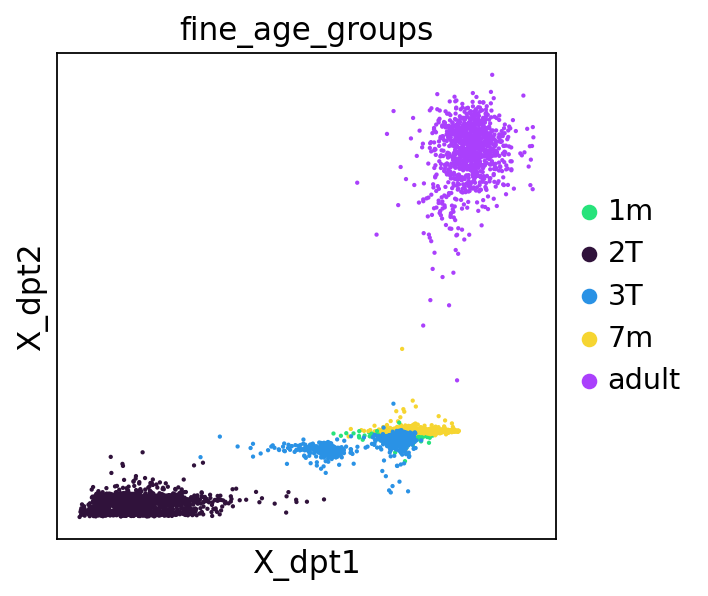

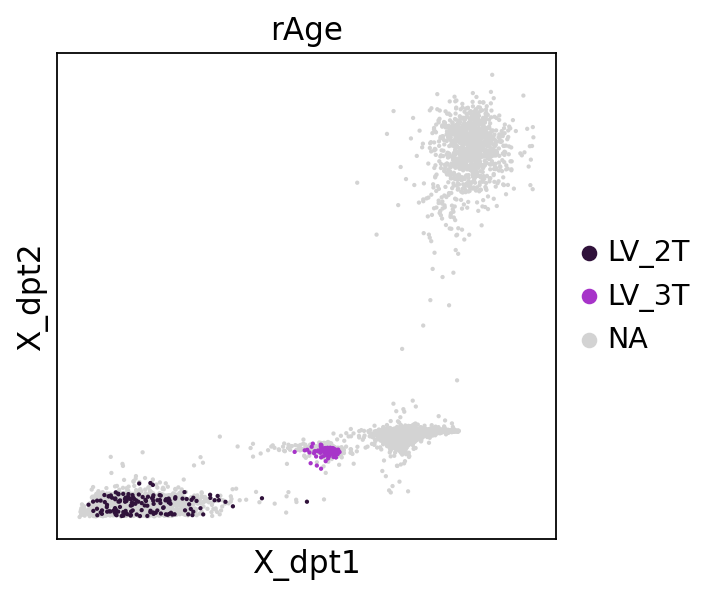

In [27]:
adata2.obsm['X_dpt']=adata2.obs[['mCG_dpt','3C_dpt']].values
sc.pl.embedding(adata2,basis='X_dpt',color=['fine_age_groups'],
                palette=['#27e37b','#30123b','#2a92e5','#f6d531','#aa40fc'],save='MSN-D1EPHA4_mmxDPT_allAges.pdf')
sc.pl.embedding(adata2,basis='X_dpt',color=['rAge'],palette=['#27e37b','#aa40fc','#2a92e5','#f6d531','#30123b','#a734c9']
                ,save='MSN-D1EPHA4_mmxDPT_allAges_LVnLV.pdf',vmin=-1,groups=['LV_2T','LV_3T'])